In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside Jupyter Notebook
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv("../data/raw/salary.csv")
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [6]:
df.shape
df.columns


Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [8]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [9]:
df.describe(include="object")

C:\Users\91992\AppData\Local\Temp\ipykernel_29860\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,job_title,education_level,industry,company_size,location,remote_work
count,250000,250000,250000,250000,250000,250000
unique,12,5,10,5,10,3
top,Backend Developer,Master,Finance,Large,Australia,No
freq,21125,50352,25393,50254,25258,83621


In [11]:
# Missing values count
missing = df.isnull().sum()
print(missing)

# Missing values percentage
missing_percentage = (missing / len(df)) * 100
print(missing_percentage)

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64
job_title           0.0
experience_years    0.0
education_level     0.0
skills_count        0.0
industry            0.0
company_size        0.0
location            0.0
remote_work         0.0
certifications      0.0
salary              0.0
dtype: float64


In [12]:
# Count duplicate rows
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [13]:
df.dtypes

job_title             str
experience_years    int64
education_level       str
skills_count        int64
industry              str
company_size          str
location              str
remote_work           str
certifications      int64
salary              int64
dtype: object

In [14]:
feature_inventory = pd.DataFrame({
    "Feature": [
        "job_title",
        "experience_years",
        "education_level",
        "skills_count",
        "industry",
        "company_size",
        "location",
        "remote_work",
        "certifications",
        "salary"
    ],

    "Description": [
        "Employee's job title",
        "Years of work experience",
        "Highest education level",
        "Number of skills",
        "Industry where employee works",
        "Company size",
        "Employee location",
        "Whether employee works remotely",
        "Number of certifications",
        "Employee salary"
    ],

    "Role": [
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Target"
    ]
})

feature_inventory

,Feature,Description,Role
0,job_title,Employee's job title,Feature
1,experience_years,Years of work experience,Feature
2,education_level,Highest education level,Feature
3,skills_count,Number of skills,Feature
4,industry,Industry where employee works,Feature
5,company_size,Company size,Feature
6,location,Employee location,Feature
7,remote_work,Whether employee works remotely,Feature
8,certifications,Number of certifications,Feature
9,salary,Employee salary,Target


In [15]:
feature_inventory.to_csv("../data/processed/feature_inventory.csv", index=False)

In [16]:
import os

os.listdir("../data/processed")

['feature_inventory.csv']

In [17]:
df["salary"].describe()

count    250000.000000
mean     145718.080524
std       37407.952729
min       31867.000000
25%      119358.000000
50%      143453.000000
75%      169492.000000
max      333046.000000
Name: salary, dtype: float64

In [18]:
print("Mean Salary   :", df["salary"].mean())
print("Median Salary :", df["salary"].median())
print("Mode Salary   :", df["salary"].mode()[0])
print("Minimum Salary:", df["salary"].min())
print("Maximum Salary:", df["salary"].max())
print("Standard Deviation:", df["salary"].std())

Mean Salary   : 145718.080524
Median Salary : 143453.0
Mode Salary   : 140468
Minimum Salary: 31867
Maximum Salary: 333046
Standard Deviation: 37407.952729244156


In [19]:
df.nunique()

job_title               12
experience_years        21
education_level          5
skills_count            19
industry                10
company_size             5
location                10
remote_work              3
certifications           6
salary              118956
dtype: int64

In [24]:
df["remote_work"].unique()

<StringArray>
['Hybrid', 'No', 'Yes']
Length: 3, dtype: str

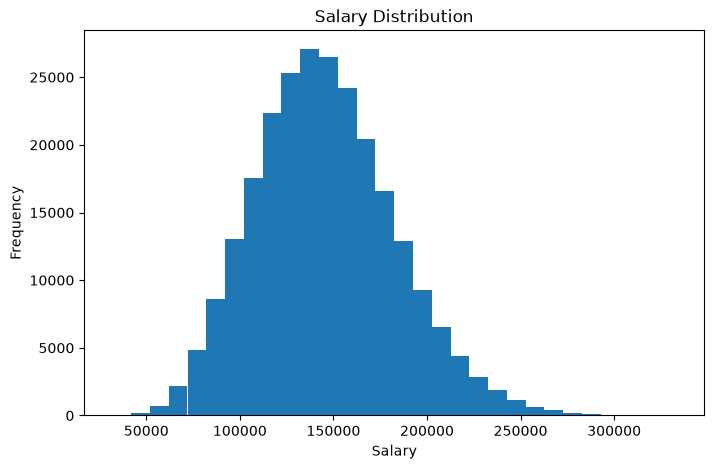

In [25]:
plt.figure(figsize=(8,5))

plt.hist(df["salary"], bins=30)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.show()

C:\Users\91992\AppData\Local\Temp\ipykernel_29860\1223859578.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["salary"], vert=False)


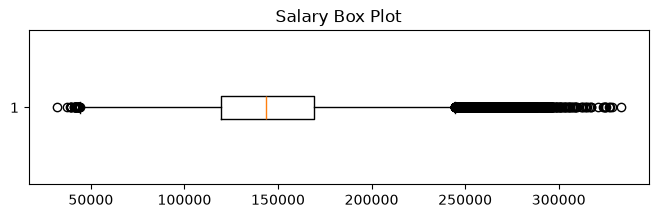

In [26]:
plt.figure(figsize=(8, 2))

plt.boxplot(df["salary"], vert=False)

plt.title("Salary Box Plot")

plt.show()

In [27]:
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["salary"] < lower_bound) | (df["salary"] > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 2336


In [28]:
df["experience_years"].describe()

count    250000.000000
mean         10.005408
std           6.060602
min           0.000000
25%           5.000000
50%          10.000000
75%          15.000000
max          20.000000
Name: experience_years, dtype: float64

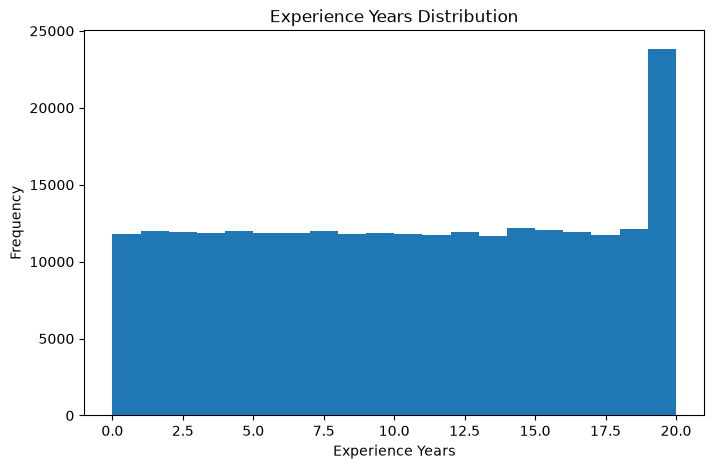

In [29]:
plt.figure(figsize=(8, 5))

plt.hist(df["experience_years"], bins=20)

plt.title("Experience Years Distribution")
plt.xlabel("Experience Years")
plt.ylabel("Frequency")

plt.show()

C:\Users\91992\AppData\Local\Temp\ipykernel_29860\2074461662.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["experience_years"], vert=False)


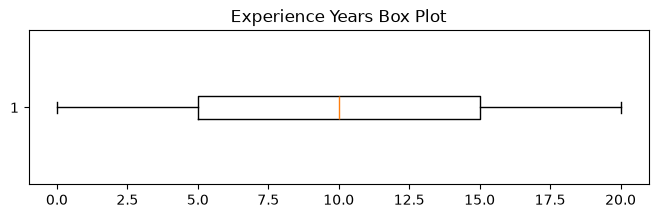

In [30]:
plt.figure(figsize=(8, 2))

plt.boxplot(df["experience_years"], vert=False)

plt.title("Experience Years Box Plot")

plt.show()

In [31]:
Q1 = df["experience_years"].quantile(0.25)
Q3 = df["experience_years"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["experience_years"] < lower_bound) |
    (df["experience_years"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 0


In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
experience_years,250000.0,10.005408,6.060602,0.0,5.0,10.0,15.0,20.0
skills_count,250000.0,9.997812,5.479288,1.0,5.0,10.0,15.0,19.0
certifications,250000.0,2.491928,1.706475,0.0,1.0,2.0,4.0,5.0
salary,250000.0,145718.080524,37407.952729,31867.0,119358.0,143453.0,169492.0,333046.0


In [33]:
df.describe(include="object").T

C:\Users\91992\AppData\Local\Temp\ipykernel_29860\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
job_title,250000,12,Backend Developer,21125
education_level,250000,5,Master,50352
industry,250000,10,Finance,25393
company_size,250000,5,Large,50254
location,250000,10,Australia,25258
remote_work,250000,3,No,83621


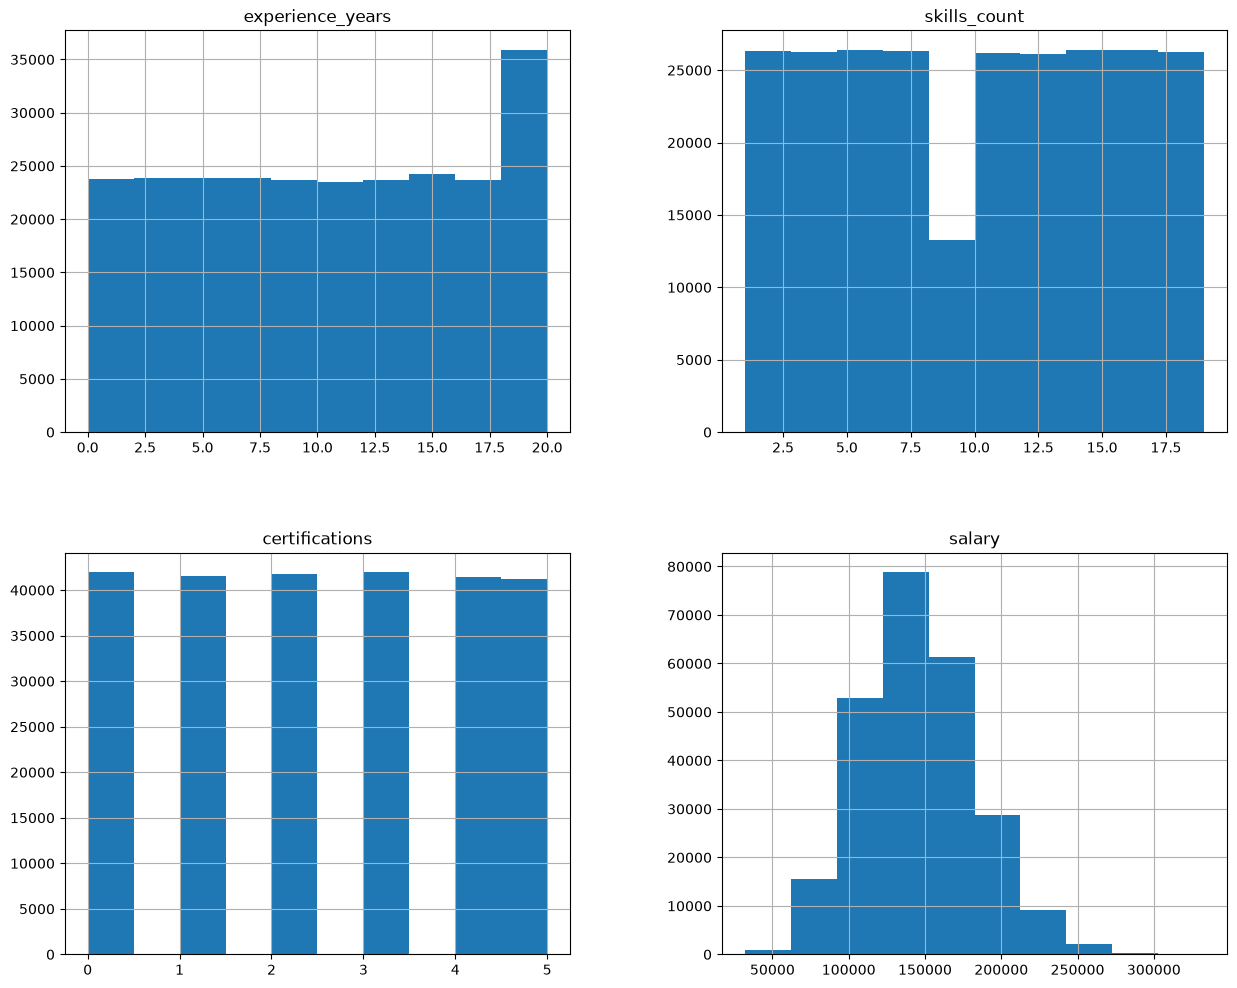

In [34]:
df.hist(figsize=(15, 12))
plt.show()

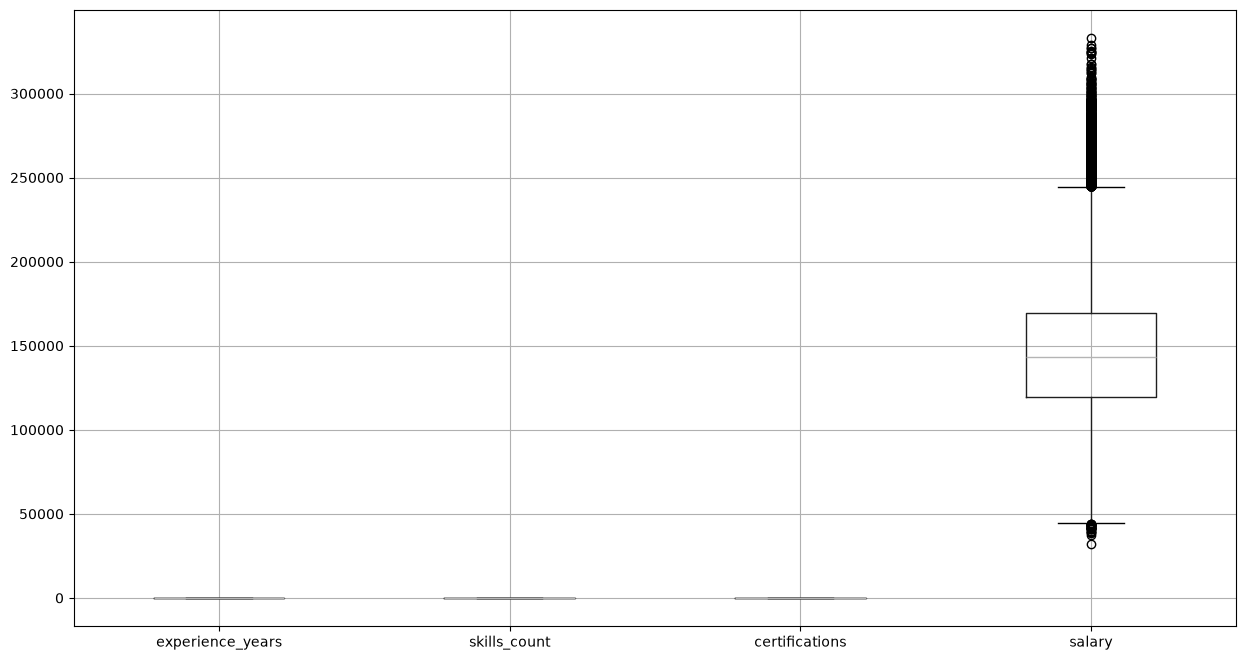

In [35]:
df.boxplot(figsize=(15, 8))
plt.show()

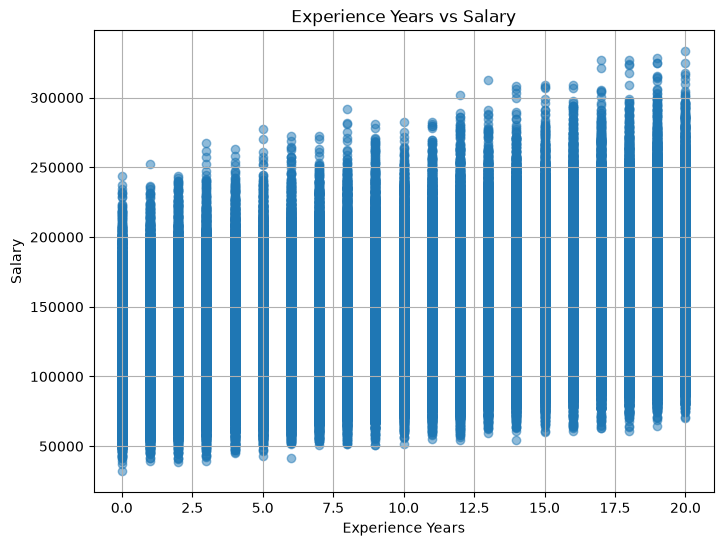

In [38]:

# Create the figure
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(
    df["experience_years"],
    df["salary"],
    alpha=0.5
)

# Add title and labels
plt.title("Experience Years vs Salary")
plt.xlabel("Experience Years")
plt.ylabel("Salary")

# Add grid
plt.grid(True)

# Display the plot
plt.show()

In [40]:
# Select all columns except the target column
X = df.drop(columns='salary')

# Select the target column
y = df['salary']

In [41]:
print("Features:")
print(X.head())

print()

print("Target:")
print(y.head())

Features:
            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  
0     Healthcare       Medium      India      Hybrid               2  
1        Telecom        Small  Australia          No               0  
2          Media       Medium  Singapore          No               1  
3         Retail       Medium     Canada         Yes               0  
4  Manufacturing        Large     Sweden         Yes               0  

Target:
0    109413
1     93764
2    148123
3    189123
4    165069
Name: salary, dtype: int64


In [42]:
print(X.shape)
print(y.shape)

(250000, 9)
(250000,)
